Creating Custom Visualizations with Seaborn

Retail Chain Executive Dashboard

Lela Hamilton

March 2026

Create professional data visualizations to understand customer behavior,
sales patterns, and business performance for a growing retail chain.


## Setup: Import Libraries and Load Data


In [1]:
# Install seaborn if needed (run this once, then you can comment it out)
# !pip install seaborn

# Import our libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for professional-looking charts
# This one line makes ALL your charts look better automatically!
sns.set_style("whitegrid")

# Set the color palette - "Set2" gives us professional, distinct colors
sns.set_palette("Set2")

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
# Load all 3 CSV files (same data from Week 9!)
customers = pd.read_csv('customers_wk9_thurs.csv')
products = pd.read_csv('products_wk9_thurs.csv')
sales = pd.read_csv('sales_wk9_thurs.csv')

# Quick preview
print(f"Customers: {customers.shape[0]} rows, {customers.shape[1]} columns")
print(f"Products: {products.shape[0]} rows, {products.shape[1]} columns")
print(f"Sales: {sales.shape[0]} rows, {sales.shape[1]} columns")


Customers: 100 rows, 8 columns
Products: 60 rows, 6 columns
Sales: 150 rows, 6 columns


---
## Data Preparation

Before making charts, we need to prepare the data. This is the same
groupby and merge concepts from Week 9 — just applied to visualization!


In [3]:
# STEP 1: Merge sales with products to get category information
# This is like VLOOKUP in Excel or JOIN in SQL
# We need to know which CATEGORY each sale belongs to
sales_products = sales.merge(products[['product_id', 'category', 'price']], on='product_id', how='left')

# Convert total_amount to numeric (remove any formatting issues)
sales_products['total_amount'] = pd.to_numeric(sales_products['total_amount'], errors='coerce')

# Convert transaction_date to datetime so we can extract day of week
sales_products['transaction_date'] = pd.to_datetime(sales_products['transaction_date'])

# Extract day of week name (Monday, Tuesday, etc.)
# This is the same .dt accessor we learned in Week 9!
sales_products['day_of_week'] = sales_products['transaction_date'].dt.day_name()

print("Sales + Products merged!")
print(f"Combined shape: {sales_products.shape}")
sales_products.head()


Sales + Products merged!
Combined shape: (150, 9)


,sale_id,customer_id,product_id,transaction_date,quantity,total_amount,category,price,day_of_week
0,1,1,1,2022-02-10 14:30:00,1,79.99,Electronics,79.99,Thursday
1,2,2,3,2022-02-15 10:15:00,2,39.98,Home & Garden,19.99,Tuesday
2,3,3,5,2022-02-20 16:45:00,1,34.99,Sports & Outdoors,34.99,Sunday
3,4,4,2,2022-02-25 11:20:00,3,74.97,Clothing,24.99,Friday
4,5,5,4,2022-03-01 13:10:00,1,89.99,Accessories,89.99,Tuesday


In [4]:
# STEP 2: Calculate Revenue by Category
# This is groupby + sum — same as Week 9 and your SQL GROUP BY!
revenue_by_category = sales_products.groupby('category')['total_amount'].sum().reset_index()
revenue_by_category = revenue_by_category.sort_values('total_amount', ascending=True)
revenue_by_category.columns = ['Category', 'Total Revenue']

print("Revenue by Category:")
print(revenue_by_category)


Revenue by Category:
            Category  Total Revenue
3      Home & Garden        1541.46
0        Accessories        2053.25
1           Clothing        2745.39
2        Electronics        3524.29
4  Sports & Outdoors        3544.64


In [5]:
# STEP 3: Customer count by State (Top 6)
# value_counts() counts how many customers per state — like COUNTIF in Excel
customers_by_state = customers['state'].value_counts().head(6).reset_index()
customers_by_state.columns = ['State', 'Customer Count']
# Sort for horizontal bar chart
customers_by_state = customers_by_state.sort_values('Customer Count', ascending=True)

print("Top 6 States by Customer Count:")
print(customers_by_state)


Top 6 States by Customer Count:
  State  Customer Count
0    CA              20
1    NY              20
2    TX              20
3    FL              20
4    IL              20


In [6]:
# STEP 4: Average transaction by day of week
# groupby day_of_week and calculate the mean — same as our Week 9 analysis!
daily_avg = sales_products.groupby('day_of_week')['total_amount'].mean().reset_index()
daily_avg.columns = ['Day', 'Avg Transaction']

# Set the correct day order (Monday first, Sunday last)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_avg['Day'] = pd.Categorical(daily_avg['Day'], categories=day_order, ordered=True)
daily_avg = daily_avg.sort_values('Day')

print("Average Transaction by Day:")
print(daily_avg)


Average Transaction by Day:
         Day  Avg Transaction
1     Monday        90.927500
5    Tuesday        74.028636
6  Wednesday        96.071905
4   Thursday       102.267619
0     Friday       100.940833
2   Saturday        61.121905
3     Sunday        99.551429


---
# Part 1: Executive Dashboard (2x2 Grid)

Now we build 4 charts in one figure! The key concept here is **subplots** —
think of it like splitting a page into 4 sections, and putting one chart
in each section.

**fig, axes = plt.subplots(2, 2)** means:
- fig = the whole page
- axes = the 4 chart areas (2 rows, 2 columns)
- axes[0, 0] = top left, axes[0, 1] = top right
- axes[1, 0] = bottom left, axes[1, 1] = bottom right


C:\Users\Owner\AppData\Local\Temp\ipykernel_15156\1468405078.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_category, x='Total Revenue', y='Category',
C:\Users\Owner\AppData\Local\Temp\ipykernel_15156\1468405078.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=customers_by_state, x='Customer Count', y='State',


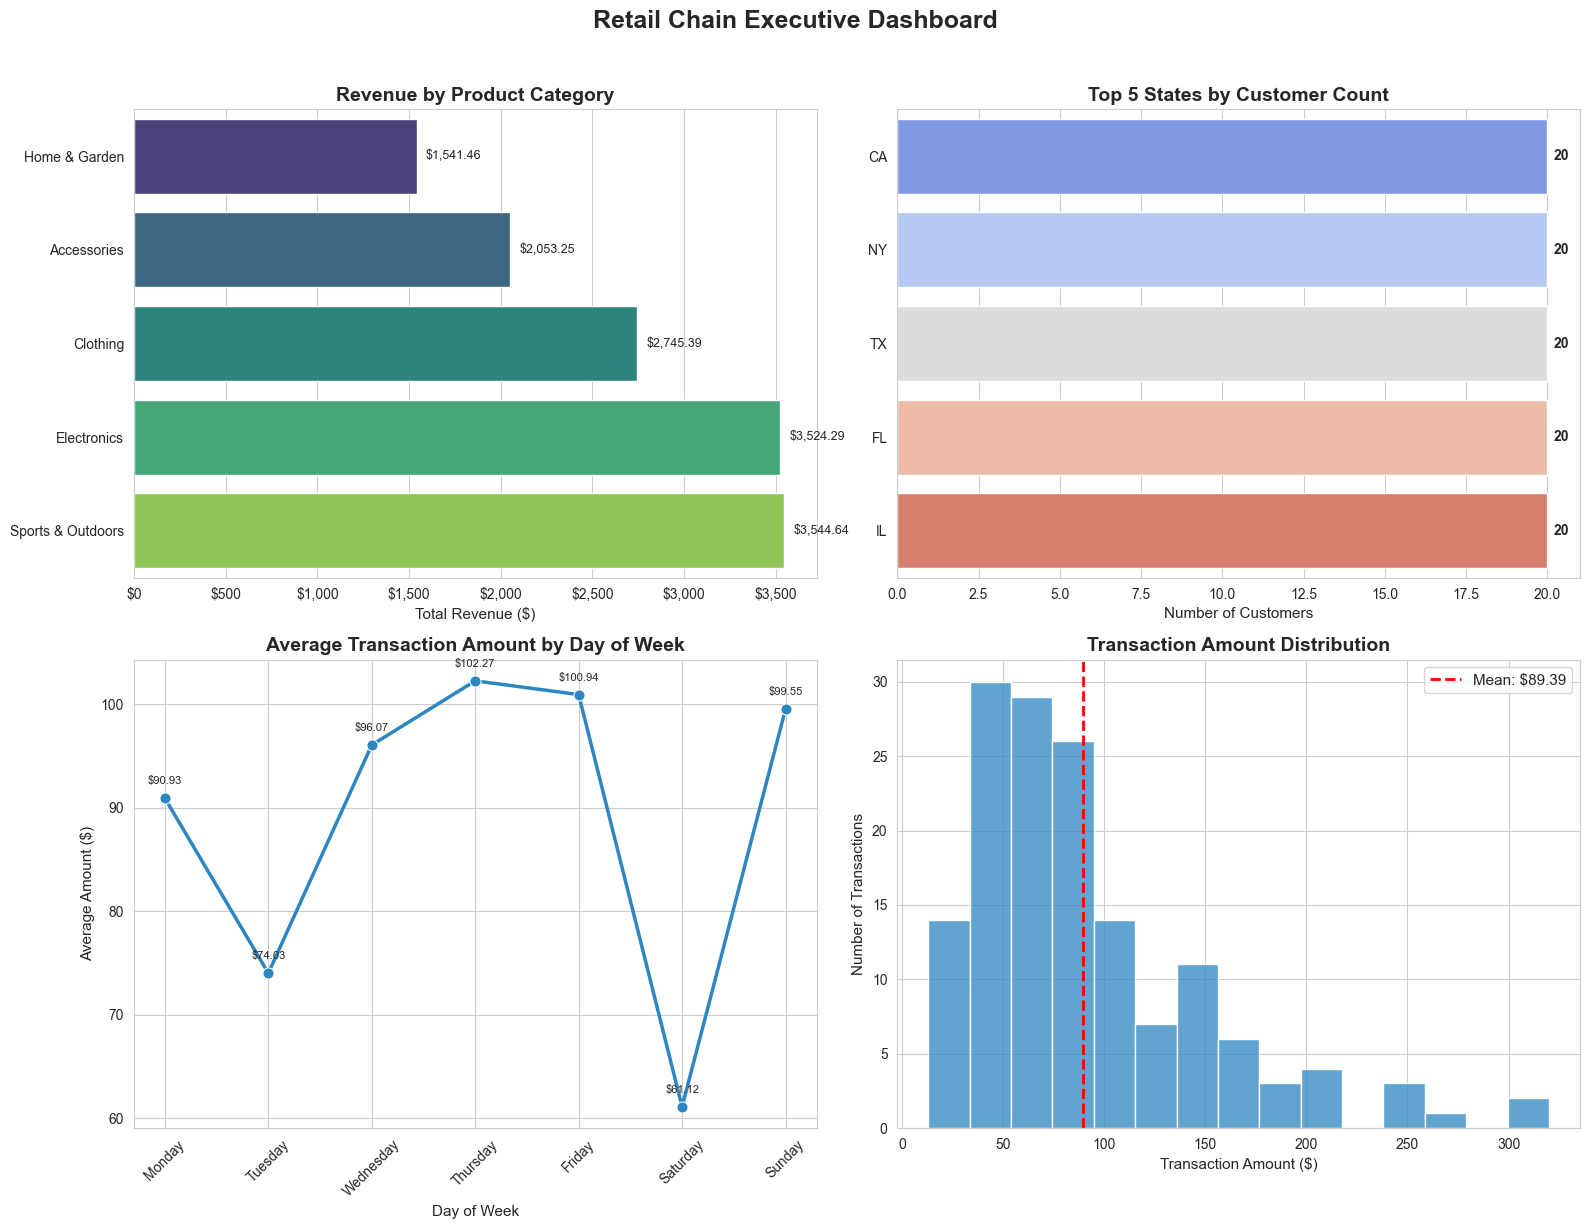

Executive Dashboard saved!


In [10]:
# Create the 2x2 dashboard
# figsize=(16, 12) makes it big enough to read
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Add a main title for the whole dashboard
fig.suptitle('Retail Chain Executive Dashboard', fontsize=18, fontweight='bold', y=1.02)

# ============================================
# CHART 1: Revenue by Product Category (Top Left)
# ============================================
# barh = horizontal bar chart
# ax=axes[0, 0] tells seaborn to put this chart in the top-left spot
sns.barplot(data=revenue_by_category, x='Total Revenue', y='Category',
            ax=axes[0, 0], palette='viridis')

axes[0, 0].set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Revenue ($)', fontsize=11)
axes[0, 0].set_ylabel('')

# Format x-axis to show dollar signs
# This makes numbers look like $50,000 instead of 50000
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add value labels on the bars
for i, v in enumerate(revenue_by_category['Total Revenue']):
    axes[0, 0].text(v + 50, i, f'${v:,.2f}', va='center', fontsize=9)

# ============================================
# CHART 2: Customer Distribution by State (Top Right)
# ============================================
sns.barplot(data=customers_by_state, x='Customer Count', y='State',
            ax=axes[0, 1], palette='coolwarm')

axes[0, 1].set_title('Top 5 States by Customer Count', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Number of Customers', fontsize=11)
axes[0, 1].set_ylabel('')

# Add value labels
for i, v in enumerate(customers_by_state['Customer Count']):
    axes[0, 1].text(v + 0.2, i, str(v), va='center', fontsize=10, fontweight='bold')

# ============================================
# CHART 3: Daily Transaction Patterns (Bottom Left)
# ============================================
# lineplot creates a line chart — great for showing trends over time
sns.lineplot(data=daily_avg, x='Day', y='Avg Transaction',
             ax=axes[1, 0], marker='o', linewidth=2.5, markersize=8, color='#2E86C1')

axes[1, 0].set_title('Average Transaction Amount by Day of Week', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week', fontsize=11)
axes[1, 0].set_ylabel('Average Amount ($)', fontsize=11)

# Rotate day names so they don't overlap
axes[1, 0].tick_params(axis='x', rotation=45)

# Add value labels above each point
for idx, row in daily_avg.iterrows():
    axes[1, 0].annotate(f'${row["Avg Transaction"]:.2f}',
                         xy=(row['Day'], row['Avg Transaction']),
                         xytext=(0, 10), textcoords='offset points',
                         ha='center', fontsize=8)

# ============================================
# CHART 4: Transaction Amount Distribution (Bottom Right)
# ============================================
# histplot creates a histogram — shows how transaction amounts are distributed
# Think of it like: "How many transactions were $0-$20? How many were $20-$40?" etc.
sns.histplot(data=sales_products, x='total_amount', bins=15,
             ax=axes[1, 1], kde=False, color='#2E86C1', edgecolor='white')

# Add a vertical line showing the MEAN (average) transaction
mean_val = sales_products['total_amount'].mean()
axes[1, 1].axvline(x=mean_val, color='red', linestyle='--', linewidth=2,
                    label=f'Mean: ${mean_val:.2f}')

axes[1, 1].set_title('Transaction Amount Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Transaction Amount ($)', fontsize=11)
axes[1, 1].set_ylabel('Number of Transactions', fontsize=11)
axes[1, 1].legend(fontsize=11)

# Adjust spacing so charts don't overlap
plt.tight_layout()
plt.savefig('executive_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("Executive Dashboard saved!")


---
# BONUS: Advanced Layered Visualization

This is ONE chart with 5 layers stacked on top of each other.
Think of it like building a cake — each layer adds something new.

**Layer 1:** Scatter plot (the base)
**Layer 2:** Trend line (the pattern)
**Layer 3:** Reference lines (business targets)
**Layer 4:** Statistics text (the numbers)
**Layer 5:** Callout annotations (the insights)


## Data Preparation for Bonus


In [8]:
# STEP 1: Merge customers with sales to see spending per customer
# First, calculate total spending and purchase count for each customer
customer_spending = sales.groupby('customer_id').agg(
    total_spending=('total_amount', 'sum'),
    purchase_count=('sale_id', 'count')
).reset_index()

# Convert total_spending to numeric
customer_spending['total_spending'] = pd.to_numeric(customer_spending['total_spending'], errors='coerce')

# STEP 2: Merge with customer demographics (age, income, state)
customer_analysis = customers.merge(customer_spending, on='customer_id', how='left')

# Fill customers with no purchases with 0
customer_analysis['total_spending'] = customer_analysis['total_spending'].fillna(0)
customer_analysis['purchase_count'] = customer_analysis['purchase_count'].fillna(0)

# STEP 3: Create age groups using pd.cut()
# This is like an IF statement — it assigns each customer to a group based on age
# Same concept as CASE WHEN in SQL or nested IF in Excel
customer_analysis['age_group'] = pd.cut(
    customer_analysis['age'],
    bins=[0, 29, 45, 60, 100],
    labels=['Under 30', '30-45', '46-60', 'Over 60']
)

print("Customer Analysis Data Ready!")
print(f"Shape: {customer_analysis.shape}")
print(f"\nAge Group Distribution:")
print(customer_analysis['age_group'].value_counts().sort_index())
print(f"\nSample data:")
customer_analysis[['first_name', 'age', 'age_group', 'income', 'total_spending', 'purchase_count']].head(10)


Customer Analysis Data Ready!
Shape: (100, 11)

Age Group Distribution:
age_group
Under 30    16
30-45       70
46-60       14
Over 60      0
Name: count, dtype: int64

Sample data:


,first_name,age,age_group,income,total_spending,purchase_count
0,John,34,30-45,75000,229.98,2.0
1,Sarah,28,Under 30,82000,179.96,2.0
2,Michael,45,30-45,95000,154.98,2.0
3,Emily,31,30-45,68000,234.95,2.0
4,David,52,46-60,110000,149.98,2.0
5,Lisa,29,Under 30,71000,219.96,2.0
6,Robert,41,30-45,88000,169.98,2.0
7,Jennifer,36,30-45,79000,174.96,2.0
8,William,48,46-60,102000,139.96,2.0
9,Jessica,26,Under 30,63000,94.98,2.0


## Building the 5-Layer Chart


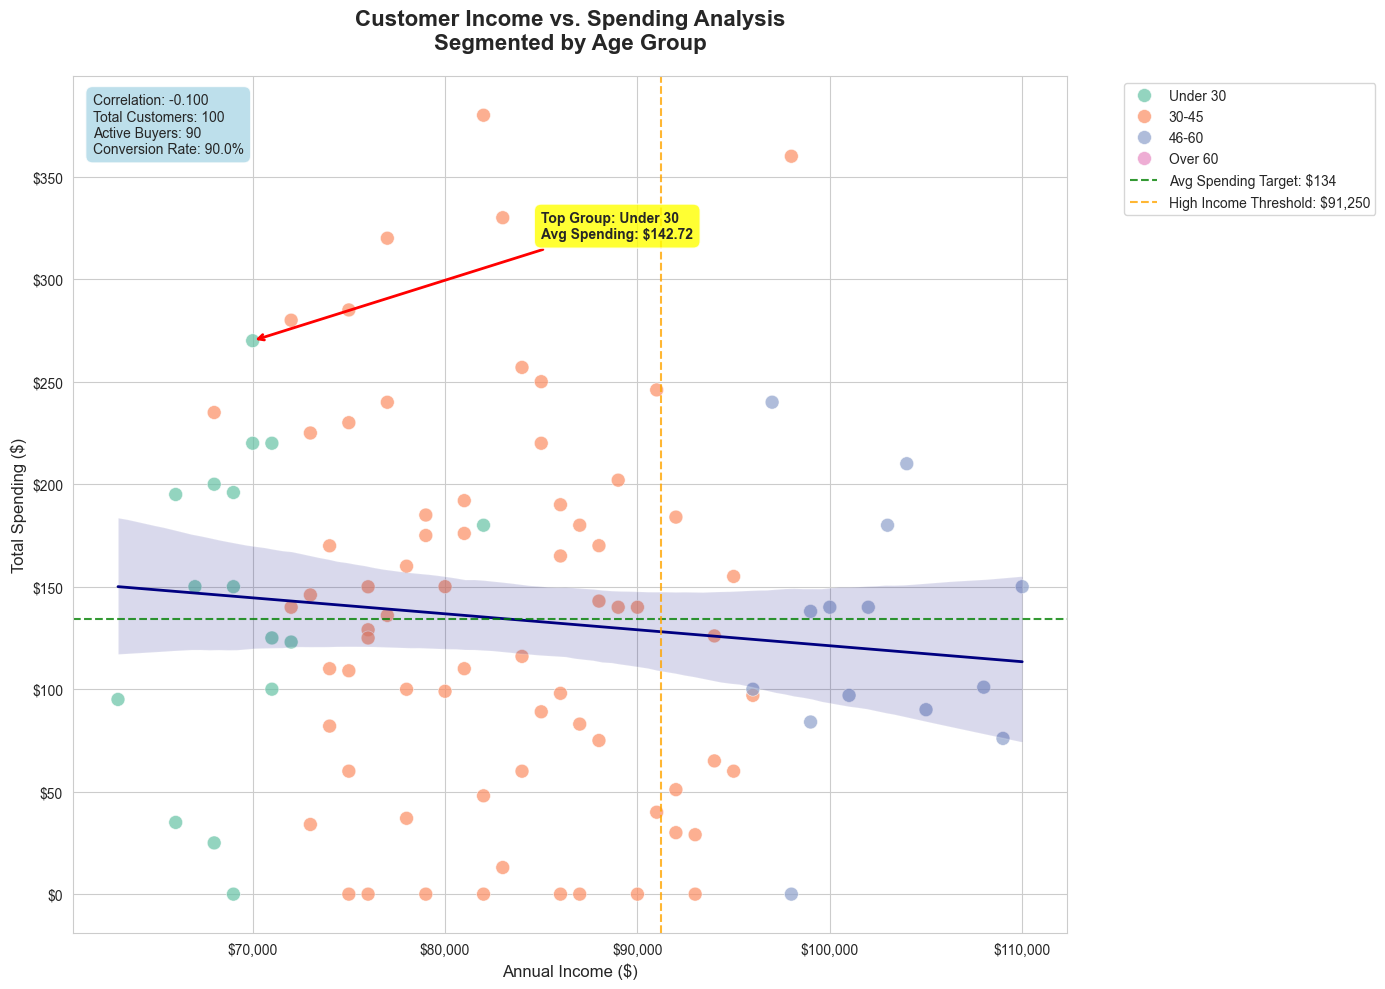

Advanced Layered Visualization saved!


In [9]:
# Create the figure — one large chart
fig, ax = plt.subplots(figsize=(14, 10))

# ============================================
# LAYER 1: Foundation Scatter Plot
# ============================================
# scatterplot shows each customer as a dot
# x = income, y = total spending
# hue = color by age group (different color for each group)
# alpha = transparency (0.7 means slightly see-through so overlapping dots are visible)
scatter = sns.scatterplot(
    data=customer_analysis,
    x='income', y='total_spending',
    hue='age_group',
    alpha=0.7,
    s=100,
    ax=ax,
    palette='Set2',
    edgecolor='white',
    linewidth=0.5
)

# ============================================
# LAYER 2: Statistical Trend Line (Regression)
# ============================================
# regplot adds a regression line — shows the TREND
# "As income goes up, does spending go up too?"
# The shaded area = confidence interval (how reliable the trend is)
# scatter=False means don't draw dots again (we already did that in Layer 1)
sns.regplot(
    data=customer_analysis,
    x='income', y='total_spending',
    scatter=False,
    ax=ax,
    color='navy',
    line_kws={'linewidth': 2, 'linestyle': '-', 'label': 'Spending Trend Line'},
    ci=95
)

# ============================================
# LAYER 3: Business Context Reference Lines
# ============================================
# These lines represent business TARGETS
# "We want customers spending above this amount" and "High income starts here"

# Horizontal line = target spending level
target_spending = customer_analysis['total_spending'].mean()
ax.axhline(y=target_spending, color='green', linestyle='--', linewidth=1.5,
           label=f'Avg Spending Target: ${target_spending:.0f}', alpha=0.8)

# Vertical line = high income threshold
high_income = customer_analysis['income'].quantile(0.75)
ax.axvline(x=high_income, color='orange', linestyle='--', linewidth=1.5,
           label=f'High Income Threshold: ${high_income:,.0f}', alpha=0.8)

# ============================================
# LAYER 4: Statistical Annotations
# ============================================
# Calculate the correlation between income and spending
# Correlation = how strongly two things are related (-1 to +1)
# +1 = perfect positive (income up → spending up)
# 0 = no relationship
# -1 = perfect negative (income up → spending down)
correlation = customer_analysis['income'].corr(customer_analysis['total_spending'])

# Count metrics
total_customers = len(customer_analysis)
active_customers = len(customer_analysis[customer_analysis['purchase_count'] > 0])
conversion_rate = (active_customers / total_customers) * 100

# Add a text box with statistics
# bbox = the background box styling
stats_text = (f'Correlation: {correlation:.3f}\n'
              f'Total Customers: {total_customers}\n'
              f'Active Buyers: {active_customers}\n'
              f'Conversion Rate: {conversion_rate:.1f}%')

ax.annotate(stats_text,
            xy=(0.02, 0.98), xycoords='axes fraction',
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.8))

# ============================================
# LAYER 5: Performance Insights
# ============================================
# Find the top-performing age group (highest average spending)
top_group = customer_analysis.groupby('age_group')['total_spending'].mean()
best_group = top_group.idxmax()
best_spending = top_group.max()

# Find a customer in the best group to point the arrow at
best_customers = customer_analysis[customer_analysis['age_group'] == best_group]
highlight_customer = best_customers.loc[best_customers['total_spending'].idxmax()]

# Add an arrow annotation pointing to the top performer
ax.annotate(
    f'Top Group: {best_group}\nAvg Spending: ${best_spending:.2f}',
    xy=(highlight_customer['income'], highlight_customer['total_spending']),
    xytext=(highlight_customer['income'] + 15000, highlight_customer['total_spending'] + 50),
    fontsize=10, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='red', linewidth=2),
    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8)
)

# ============================================
# FINAL STYLING
# ============================================
ax.set_title('Customer Income vs. Spending Analysis\nSegmented by Age Group',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Annual Income ($)', fontsize=12)
ax.set_ylabel('Total Spending ($)', fontsize=12)

# Format axes to show dollar signs
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Move legend outside the chart so it doesn't cover data
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('advanced_layered_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("Advanced Layered Visualization saved!")


In [ ]:
---
Business Insights

What the Executive Dashboard Reveals:

1. Revenue by Category shows which product lines drive the most revenue,
   helping the CEO decide where to invest marketing budget.

2. Customer Distribution by State reveals geographic concentration,
   useful for targeted regional campaigns and store expansion decisions.

3. Daily Transaction Patterns shows which days have highest average
   spending, informing staffing decisions and promotional timing.

4. Transaction Distribution shows most transactions cluster around
   a certain range, with the mean line providing a benchmark target.

What the Advanced Visualization Reveals:

The scatter plot with trend line shows the relationship between customer
income and spending. The age group coloring reveals which demographics
are the most valuable customers. The correlation coefficient quantifies
how strongly income predicts spending. Together, these insights help the
CEO target the right customer segments with the right products.
